# ML Homework 1 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW1.ipynb" to "HW1_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together


# [HW 1-1] Data Indexing
Extract sensor signal (without time column) from 0.02 seconds to 0.12 seconds by indexing the ExampleData in Github.

* Data link: 'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/ML1/ExampleData?raw=true'
* Index the data as DataFrame format
* Refer to ML1_Code1

In [ ]:
# Import the necessary packages
import numpy       as np
import pandas      as pd
import matplotlib.pyplot as plt

# Load ExampleData from Github
Path = 'https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/ML1/ExampleData?raw=true'
data = pd.read_csv(Path, sep=',',names=['time(s)', 'Acceleration(g)', 'Voltage(V)', 'Current(kA)'])
data


,time(s),Acceleration(g),Voltage(V),Current(kA)
0,0.000000,0.016440,-0.014200,0.001433
1,0.000078,0.013822,-0.015707,0.001504
2,0.000156,0.019431,-0.016963,0.001433
3,0.000234,0.003726,-0.017248,0.001549
4,0.000313,0.022049,-0.009840,0.001864
...,...,...,...,...
2769,0.216330,0.077392,0.002404,0.003453
2770,0.216410,0.030276,0.003952,0.003498
2771,0.216480,0.017188,0.005504,0.003397
2772,0.216560,0.037754,-0.000108,0.003506


In [ ]:
# Data indexing
Sensordata = data.iloc[:,1:]
Sensordata

,Acceleration(g),Voltage(V),Current(kA)
0,0.016440,-0.014200,0.001433
1,0.013822,-0.015707,0.001504
2,0.019431,-0.016963,0.001433
3,0.003726,-0.017248,0.001549
4,0.022049,-0.009840,0.001864
...,...,...,...
2769,0.077392,0.002404,0.003453
2770,0.030276,0.003952,0.003498
2771,0.017188,0.005504,0.003397
2772,0.037754,-0.000108,0.003506


In [ ]:
StartPoint = np.where(data.iloc[:,0].values == 0.02)[0][0]
EndPoint   = np.where(data.iloc[:,0].values == 0.12)[0][0]

StartPoint, EndPoint

(np.int64(256), np.int64(1536))

In [ ]:
SensorData=Sensordata.iloc[StartPoint:EndPoint+1,:]
SensorData

,Acceleration(g),Voltage(V),Current(kA)
256,-0.40050,1.6026,3.6504
257,-0.47753,1.5377,3.5958
258,-0.58822,1.4383,3.5342
259,-0.73779,1.3535,3.4622
260,-0.85521,1.2843,3.3858
...,...,...,...
1532,-0.44388,1.7312,5.1246
1533,-0.43116,1.6670,5.0836
1534,-0.66899,1.6050,5.0335
1535,-0.57326,1.5342,4.9750


# [HW 1-2] Data Processing & Plotting
Plot the change in mean value every 0.01 seconds for each sensor signal in 'SensorData' above.
* Refer to ML1_Code3

In [53]:
# Feature extraction
mean1 = np.mean(SensorData.iloc[:,0])
mean2 = np.mean(SensorData.iloc[:,1])
mean3 = np.mean(SensorData.iloc[:,2])
meanvalue =np.array([mean1,mean2,mean3])
meanvalue


array([0.010311  , 0.01700924, 0.02274726])

In [56]:
meanvalue=np.zeros((1,SensorData.shape[1]))
meanvalue

array([[0., 0., 0.]])

In [57]:
meanvalue = np.zeros((1, SensorData.shape[1])) # Re-initialize meanvalue with correct shape based on SensorData

for i in range(SensorData.shape[1]):
    meanvalue[0,i]=np.mean(SensorData.iloc[:,i]) # Calculate mean for each column
meanvalue

array([[0.010311  , 0.01700924, 0.02274726]])

In [66]:
mean_value = np.zeros((11, SensorData.shape[1]))



for sensor in range(SensorData.shape[1]):
    for time in range(11):
        mean_value[time, sensor] = np.mean(
           SensorData.iloc[time*128:(time+1)*128, sensor]
        )
mean_value

array([[-6.88153512e-02, -4.75943409e-01, -6.95329720e-01],
       [ 1.40033434e-02,  7.22880259e-01,  1.52815897e+00],
       [ 4.12313805e-03, -6.85222168e-01, -1.58835158e+00],
       [ 7.66781289e-02,  4.54910652e-01,  1.42075752e+00],
       [ 6.19882500e-02,  2.20500403e-01, -3.37495118e-01],
       [-1.35591930e-01, -7.44915453e-01, -1.06781444e+00],
       [ 3.05241854e-02,  7.56620389e-01,  1.63255540e+00],
       [-3.24115156e-03, -6.99038574e-01, -1.73218367e+00],
       [ 8.52008937e-02,  4.03614779e-01,  1.46960270e+00],
       [ 4.39856927e-02,  2.05563740e-01, -4.40579484e-01],
       [-7.25080000e-01,  1.44060000e+00,  4.90620000e+00]])

In [67]:
TimeArr = np.arange(2,13)/100
print(TimeArr.shape)
TimeArr

(11,)


array([0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11, 0.12])

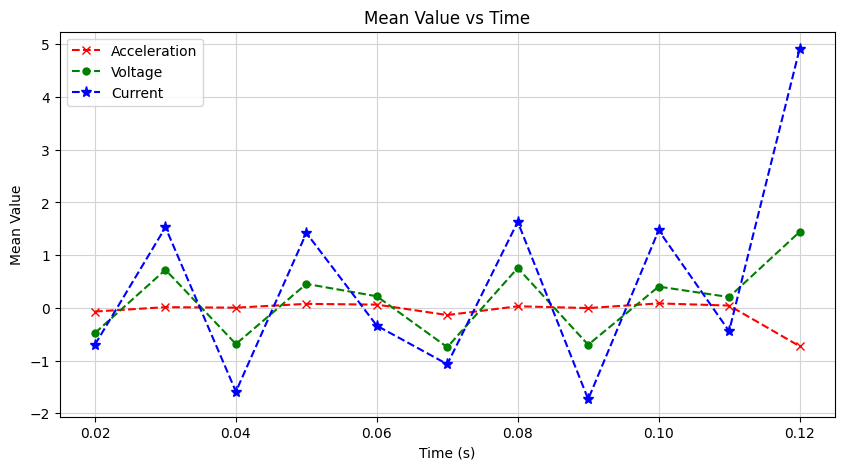

In [68]:
# Plot graphs
plt.figure(figsize=(10, 5))
plt.plot(TimeArr, mean_value[:, 0], label='Acceleration',ls = '--', c = 'r', marker = 'x', ms = 6, mfc = 'r', mec = 'r')
plt.plot(TimeArr, mean_value[:, 1], label='Voltage',ls = '--', c = 'g', marker = 'o', ms = 5, mfc = 'g', mec = 'g')
plt.plot(TimeArr, mean_value[:, 2], label='Current',ls = '--', c = 'b', marker = '*', ms = 8, mfc = 'b', mec = 'b')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Mean Value')
plt.title('Mean Value vs Time')
plt.grid(True,c='lightgrey')
plt.show()


## ML1 and ML2 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML1 and ML2.

---
We learned how to import packages, read CSV files from GitHub, index and filter datasets, and save and plot the data. We also explored creating arrays and using array and DataFrame functions to modify and access data efficiently.
---

### Q2. What skills did you have to develop to accomplish this project?

---

I developed skills in Python programming, data handling with pandas and NumPy, and visualizing data with Matplotlib.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

The most beneficial aspects were learning to manipulate and analyze datasets, filter and process data efficiently, and visualize results clearly, which strengthened both my programming and data analysis skills

---

### Q4. What challenges did you encounter in completing the project?

---

The main challenges were correctly indexing the data and extracting the required features from large datasets. Ensuring the slices and calculations aligned with the intended time windows or columns required careful attention.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

I overcame the challenges by carefully reviewing the dataset structure, using systematic indexing, and testing small data segments before applying operations to the full dataset. I also referred to documentation and examples to correctly extract and compute the features.

---